<a href="https://colab.research.google.com/github/talhanoor23/algorithmic-trading/blob/main/cdlPattern_Practise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Install TA-Lib C library from conda-forge
!curl -L \
'https://anaconda.org/conda-forge/libta-lib/0.4.0/download/linux-64/libta-lib-0.4.0-h166bdaf_1.tar.bz2' \
| tar xj -C /usr/lib/x86_64-linux-gnu/ lib --strip-components=1

# 2. Install conda-package-handling and extract Python wrapper
!pip install conda-package-handling
!wget https://anaconda.org/conda-forge/ta-lib/0.5.1/download/linux-64/ta-lib-0.5.1-py311h9ecbd09_0.conda
!cph x ta-lib-0.5.1-py311h9ecbd09_0.conda

# 3. Move the extracted wrapper into site-packages
!mv ./ta-lib-0.5.1-py311h9ecbd09_0/lib/python3.11/site-packages/talib \
     /usr/local/lib/python3.11/dist-packages/

In [ ]:
import talib
print(len(talib.get_functions()), "functions available:")
print(talib.get_functions()[:5])   # shows first few indicators
print("\nGroups:", list(talib.get_function_groups().keys()))

158 functions available:
['HT_DCPERIOD', 'HT_DCPHASE', 'HT_PHASOR', 'HT_SINE', 'HT_TRENDMODE']

Groups: ['Cycle Indicators', 'Math Operators', 'Math Transform', 'Momentum Indicators', 'Overlap Studies', 'Pattern Recognition', 'Price Transform', 'Statistic Functions', 'Volatility Indicators', 'Volume Indicators']


In [ ]:
!pip install --upgrade pip
!pip uninstall -y numpy pandas_ta
!pip install numpy==1.24.3 pandas_ta

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 17.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 119.3 MB/s eta 0:00:00
  DEPRECATION: Building 'pandas_ta' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'pandas_ta'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for pandas_ta: filename=pandas_ta-0.3.14b0-py3-none-any.whl size=218910 sha

In [ ]:
!pip install yfinance pandas_datareader

In [ ]:
from statsmodels.regression.rolling import RollingOLS
import pandas as pd
import pandas_ta as ta
import yfinance as yf
import pandas_datareader.data as pdr
import matplotlib.pyplot as plt
import statsmodels.api as sm
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load data
df = yf.download("BTC-USD")

# Check if columns is a MultiIndex and handle accordingly
if isinstance(df.columns, pd.MultiIndex):
    # Extract the first level of the MultiIndex and convert to lowercase
    df.columns = df.columns.get_level_values(0).str.lower()
else:
    df.columns = df.columns.str.lower()

[*********************100%***********************]  1 of 1 completed


In [ ]:
print(df.columns)
print(df.columns.name)

Index(['close', 'high', 'low', 'open', 'volume'], dtype='object', name='Price')
Price


In [ ]:
df

Price,close,high,low,open,volume
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100
...,...,...,...,...,...
2025-06-18,104883.328125,105581.851562,103602.265625,104602.070312,47318089133
2025-06-19,104684.289062,105250.890625,103940.773438,104886.773438,37333806920
2025-06-20,103309.601562,106539.382812,102372.210938,104681.031250,50951862476


In [ ]:
df.columns

Index(['close', 'high', 'low', 'open', 'volume'], dtype='object', name='Price')

In [ ]:
# Step 2: Add technical indicators
df.ta.ema(length=50, append=True)
df.ta.ema(length=200, append=True)
df.ta.macd(append=True)
df.ta.rsi(length=14, append=True)
df.ta.atr(length=14, append=True)

,ATRr_14
Date,
2014-09-17,NaN
2014-09-18,NaN
2014-09-19,NaN
2014-09-20,NaN
2014-09-21,NaN
...,...
2025-06-18,2843.224478
2025-06-19,2733.716815
2025-06-20,2836.106462


In [ ]:
df

Price,close,high,low,open,volume,EMA_50,EMA_200,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,RSI_14,ATRr_14
Date,,,,,,,,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-18,104883.328125,105581.851562,103602.265625,104602.070312,47318089133,103096.023517,93185.257672,397.048343,-438.030769,835.079112,48.181050,2843.224478
2025-06-19,104684.289062,105250.890625,103940.773438,104886.773438,37333806920,103158.308440,93299.675894,265.787555,-455.433245,721.220800,47.610542,2733.716815
2025-06-20,103309.601562,106539.382812,102372.210938,104681.031250,50951862476,103164.241504,93399.277145,50.257308,-536.770794,587.028102,43.756807,2836.106462


In [ ]:
# Correctly add candlestick pattern flags
df.ta.cdl_pattern(name=["hammer", "engulfing"], append=True)

,CDL_HAMMER,CDL_ENGULFING
Date,,
2025-03-22,0.0,0.0
2025-03-23,0.0,0.0
2025-03-24,0.0,0.0
2025-03-25,0.0,0.0
2025-03-26,0.0,0.0
...,...,...
2025-06-18,0.0,0.0
2025-06-19,0.0,0.0
2025-06-20,0.0,0.0


In [ ]:
df.ta.cdl_pattern(name="all", append=True)
# print(df.filter(like="CDL_").tail())

,CDL_2CROWS,CDL_3BLACKCROWS,CDL_3INSIDE,CDL_3LINESTRIKE,CDL_3OUTSIDE,CDL_3STARSINSOUTH,CDL_3WHITESOLDIERS,CDL_ABANDONEDBABY,CDL_ADVANCEBLOCK,CDL_BELTHOLD,...,CDL_SPINNINGTOP,CDL_STALLEDPATTERN,CDL_STICKSANDWICH,CDL_TAKURI,CDL_TASUKIGAP,CDL_THRUSTING,CDL_TRISTAR,CDL_UNIQUE3RIVER,CDL_UPSIDEGAP2CROWS,CDL_XSIDEGAP3METHODS
Date,,,,,,,,,,,,,,,,,,,,,
2014-09-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-09-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-09-19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-09-20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-09-21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-06-19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-06-20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df

Price,close,high,low,open,volume,EMA_50,EMA_200,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,...,CDL_SPINNINGTOP,CDL_STALLEDPATTERN,CDL_STICKSANDWICH,CDL_TAKURI,CDL_TASUKIGAP,CDL_THRUSTING,CDL_TRISTAR,CDL_UNIQUE3RIVER,CDL_UPSIDEGAP2CROWS,CDL_XSIDEGAP3METHODS
Date,,,,,,,,,,,,,,,,,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-18,104883.328125,105581.851562,103602.265625,104602.070312,47318089133,103096.023517,93185.257672,397.048343,-438.030769,835.079112,...,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-06-19,104684.289062,105250.890625,103940.773438,104886.773438,37333806920,103158.308440,93299.675894,265.787555,-455.433245,721.220800,...,-100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-06-20,103309.601562,106539.382812,102372.210938,104681.031250,50951862476,103164.241504,93399.277145,50.257308,-536.770794,587.028102,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df["hammer_bullish"] = (df["CDL_HAMMER"] == 100).astype(int)
df["hammer_bearish"] = (df["CDL_HAMMER"] == -100).astype(int)
df["engulfing_bullish"] = (df["CDL_ENGULFING"] == 100).astype(int)
df["engulfing_bearish"] = (df["CDL_ENGULFING"] == -100).astype(int)

In [ ]:
df

Price,close,high,low,open,volume,EMA_50,EMA_200,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,...,CDL_TASUKIGAP,CDL_THRUSTING,CDL_TRISTAR,CDL_UNIQUE3RIVER,CDL_UPSIDEGAP2CROWS,CDL_XSIDEGAP3METHODS,hammer_bullish,hammer_bearish,engulfing_bullish,engulfing_bearish
Date,,,,,,,,,,,,,,,,,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-18,104883.328125,105581.851562,103602.265625,104602.070312,47318089133,103096.023517,93185.257672,397.048343,-438.030769,835.079112,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2025-06-19,104684.289062,105250.890625,103940.773438,104886.773438,37333806920,103158.308440,93299.675894,265.787555,-455.433245,721.220800,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2025-06-20,103309.601562,106539.382812,102372.210938,104681.031250,50951862476,103164.241504,93399.277145,50.257308,-536.770794,587.028102,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0


In [ ]:
df.columns

Index(['close', 'high', 'low', 'open', 'volume', 'EMA_50', 'EMA_200',
       'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'RSI_14', 'ATRr_14',
       'CDL_2CROWS', 'CDL_3BLACKCROWS', 'CDL_3INSIDE', 'CDL_3LINESTRIKE',
       'CDL_3OUTSIDE', 'CDL_3STARSINSOUTH', 'CDL_3WHITESOLDIERS',
       'CDL_ABANDONEDBABY', 'CDL_ADVANCEBLOCK', 'CDL_BELTHOLD',
       'CDL_BREAKAWAY', 'CDL_CLOSINGMARUBOZU', 'CDL_CONCEALBABYSWALL',
       'CDL_COUNTERATTACK', 'CDL_DARKCLOUDCOVER', 'CDL_DOJI_10_0.1',
       'CDL_DOJISTAR', 'CDL_DRAGONFLYDOJI', 'CDL_ENGULFING',
       'CDL_EVENINGDOJISTAR', 'CDL_EVENINGSTAR', 'CDL_GAPSIDESIDEWHITE',
       'CDL_GRAVESTONEDOJI', 'CDL_HAMMER', 'CDL_HANGINGMAN', 'CDL_HARAMI',
       'CDL_HARAMICROSS', 'CDL_HIGHWAVE', 'CDL_HIKKAKE', 'CDL_HIKKAKEMOD',
       'CDL_HOMINGPIGEON', 'CDL_IDENTICAL3CROWS', 'CDL_INNECK', 'CDL_INSIDE',
       'CDL_INVERTEDHAMMER', 'CDL_KICKING', 'CDL_KICKINGBYLENGTH',
       'CDL_LADDERBOTTOM', 'CDL_LONGLEGGEDDOJI', 'CDL_LONGLINE',
       'CDL_MA

In [ ]:
df.dropna(inplace=True)

In [ ]:
df

Price,close,high,low,open,volume,EMA_50,EMA_200,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,...,CDL_TASUKIGAP,CDL_THRUSTING,CDL_TRISTAR,CDL_UNIQUE3RIVER,CDL_UPSIDEGAP2CROWS,CDL_XSIDEGAP3METHODS,hammer_bullish,hammer_bearish,engulfing_bullish,engulfing_bearish
Date,,,,,,,,,,,,,,,,,,,,,
2015-04-04,253.697006,255.257996,251.100006,254.291000,12493500,258.731404,310.843170,-4.193135,-0.286594,-3.906541,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2015-04-05,260.597992,260.674988,251.942001,253.761002,19649200,258.804604,310.343218,-3.252124,0.523534,-3.775657,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2015-04-06,255.492004,261.798004,254.574997,260.721008,20034200,258.674698,309.797435,-2.885118,0.712431,-3.597550,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2015-04-07,253.179993,255.804993,252.205002,255.274002,18467400,258.459219,309.234077,-2.749134,0.678733,-3.427866,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2015-04-08,245.022003,253.847000,244.214996,253.063995,30086400,257.932269,308.595151,-3.262043,0.132658,-3.394702,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-18,104883.328125,105581.851562,103602.265625,104602.070312,47318089133,103096.023517,93185.257672,397.048343,-438.030769,835.079112,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2025-06-19,104684.289062,105250.890625,103940.773438,104886.773438,37333806920,103158.308440,93299.675894,265.787555,-455.433245,721.220800,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2025-06-20,103309.601562,106539.382812,102372.210938,104681.031250,50951862476,103164.241504,93399.277145,50.257308,-536.770794,587.028102,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0


In [ ]:
df["target"] = (df["close"].shift(-1) > df["close"]).astype(int)
df.dropna(inplace=True)

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score

tscv = TimeSeriesSplit(n_splits=5)
X = df.drop(columns=["target"])
y = df["target"]

scores = []
for train_i, test_i in tscv.split(X):
    X_train, X_test = X.iloc[train_i], X.iloc[test_i]
    y_train, y_test = y.iloc[train_i], y.iloc[test_i]

In [ ]:
X_train

Price,close,high,low,open,volume,EMA_50,EMA_200,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,...,CDL_TASUKIGAP,CDL_THRUSTING,CDL_TRISTAR,CDL_UNIQUE3RIVER,CDL_UPSIDEGAP2CROWS,CDL_XSIDEGAP3METHODS,hammer_bullish,hammer_bearish,engulfing_bullish,engulfing_bearish
Date,,,,,,,,,,,,,,,,,,,,,
2015-04-04,253.697006,255.257996,251.100006,254.291000,12493500,258.731404,310.843170,-4.193135,-0.286594,-3.906541,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2015-04-05,260.597992,260.674988,251.942001,253.761002,19649200,258.804604,310.343218,-3.252124,0.523534,-3.775657,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2015-04-06,255.492004,261.798004,254.574997,260.721008,20034200,258.674698,309.797435,-2.885118,0.712431,-3.597550,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2015-04-07,253.179993,255.804993,252.205002,255.274002,18467400,258.459219,309.234077,-2.749134,0.678733,-3.427866,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2015-04-08,245.022003,253.847000,244.214996,253.063995,30086400,257.932269,308.595151,-3.262043,0.132658,-3.394702,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-10-05,27415.912109,28091.861328,27375.601562,27798.646484,11877253670,27022.719583,26985.746964,269.104565,118.926075,150.178490,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2023-10-06,27946.597656,28252.537109,27215.552734,27412.123047,13492391599,27058.950096,26995.307667,309.778362,127.679897,182.098465,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0
2023-10-07,27968.839844,28028.091797,27870.423828,27946.781250,6553044316,27094.632047,27004.994555,339.889365,126.232720,213.656645,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0


In [ ]:
y_train

,target
Date,
2015-04-04,1
2015-04-05,0
2015-04-06,0
2015-04-07,0
2015-04-08,0
...,...
2023-10-05,1
2023-10-06,1
2023-10-07,0


In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [ ]:
accuracy

0.4855305466237942

In [ ]:
!pip install mplfinance
import mplfinance as mpf

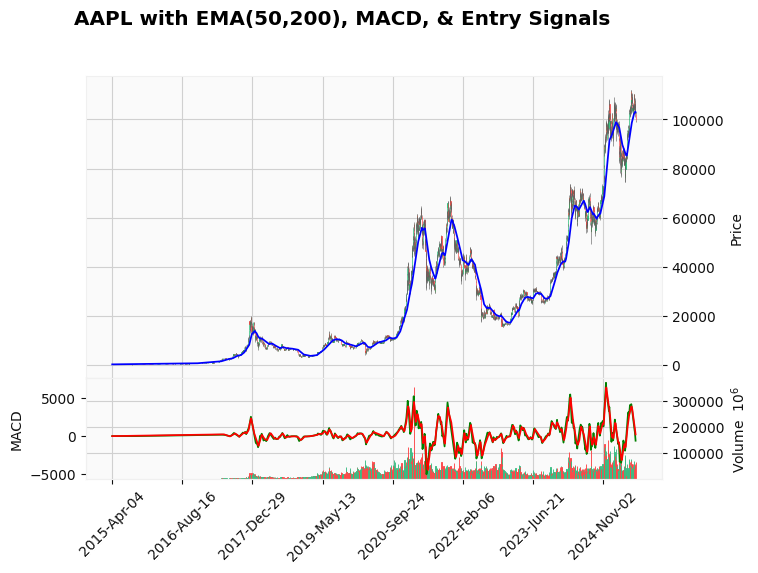

In [ ]:

# 4. Prepare indicator lines
add_plots = [
    mpf.make_addplot(df['EMA_50'], color='blue'),
    mpf.make_addplot(df['MACD_12_26_9'], panel=1, color='green', ylabel='MACD'),
    mpf.make_addplot(df['MACDs_12_26_9'], panel=1, color='red'),
]

# 5. Plot everything
mpf.plot(
    df,
    type='candle',
    style='yahoo',
    volume=True,
    title='AAPL with EMA(50,200), MACD, & Entry Signals',
    panel_ratios=(6, 2),
    addplot=add_plots,
)